# Markdown Cell
Football Natural Language Question Answering (NLQA) System

Machine Learning Model - Logistic Regression

Deep Learning Model - Convolutional Neural Network (CNN)

# Import Libraries

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Text processing
import re
import string

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# Machine Learning Evaluation
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Deep Learning
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Download NLP Resources

In [42]:
# Download required NLTK resources

nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

# Mount Google Drive

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


# Load the Dataset

In [4]:
# Dataset path

file_path = "/content/drive/MyDrive/NLP/data/results.csv"

football_df = pd.read_csv(file_path)

football_df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


# Dataset Overview

In [5]:
# Display the first five rows

football_df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


# Dataset Information

In [6]:
# Display dataset information

football_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49477 entries, 0 to 49476
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   date        49477 non-null  object 
 1   home_team   49477 non-null  object 
 2   away_team   49477 non-null  object 
 3   home_score  49433 non-null  float64
 4   away_score  49433 non-null  float64
 5   tournament  49477 non-null  object 
 6   city        49477 non-null  object 
 7   country     49477 non-null  object 
 8   neutral     49477 non-null  bool   
dtypes: bool(1), float64(2), object(6)
memory usage: 3.1+ MB


# Dataset Description

In [7]:
# Display statistical summary

football_df.describe(include="all")

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
count,49477,49477,49477,49433.000000,49433.000000,49477,49477,49477,49477
unique,16471,327,321,NaN,NaN,200,2089,269,2
top,2012-02-29,Brazil,Uruguay,NaN,NaN,Friendly,Kuala Lumpur,United States,False
freq,66,616,585,NaN,NaN,18388,745,1559,36356
mean,NaN,NaN,NaN,1.757490,1.181822,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,1.774299,1.401856,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,1.000000,0.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,2.000000,2.000000,NaN,NaN,NaN,NaN


# Check Missing Values

In [35]:
football_df.isnull().sum()

,0
date,0
home_team,0
away_team,0
home_score,44
away_score,44
tournament,0
city,0
country,0
neutral,0


The original dataset contained 44 incomplete match records where the final scores were unavailable. These missing values were retained to preserve data integrity. During answer generation, the system informs the user when score information is unavailable.

# Define Question Templates

In [24]:
question_templates = {

    "winner": [
        "Who won the match between {home} and {away}?",
        "Who won the match between {home} and {away} on {date}?",
        "Which team defeated {home} on {date}?"
    ],

    "score": [
        "What was the score between {home} and {away}?",
        "What was the final score between {home} and {away} on {date}?",
        "How many goals were scored in the match between {home} and {away} on {date}?"
    ],

    "location": [
        "Where was the match between {home} and {away} played?",
        "Which city hosted the match between {home} and {away} on {date}?",
        "Where did {home} play against {away} on {date}?"
    ],

    "date": [
        "When was the match between {home} and {away} played?",
        "On what date did {home} play against {away}?",
        "When did {home} face {away}?"
    ],

    "tournament": [
        "Which tournament was the match between {home} and {away} played in?",
        "What competition featured {home} against {away} on {date}?",
        "Which tournament included the match between {home} and {away} on {date}?"
    ],

    "draw": [
        "Did the match between {home} and {away} end in a draw?",
        "Was the match between {home} and {away} on {date} a draw?",
        "Did {home} and {away} draw on {date}?"
    ],

    "home_team": [
        "Who was the home team in the match between {home} and {away}?",
        "Which team played at home on {date}?",
        "Who hosted the match between {home} and {away} on {date}?"
    ],

    "away_team": [
        "Who was the away team in the match between {home} and {away}?",
        "Which team played away on {date}?",
        "Who was the visiting team in the match between {home} and {away} on {date}?"
    ]
}

# Create an Empty List

In [25]:
generated_questions = []

# Generate the Question Dataset

In [26]:
# Loop through every football match
for _, row in football_df.iterrows():

    # Extract match information
    home_team = row["home_team"]
    away_team = row["away_team"]

    match_date = row["date"]
    tournament = row["tournament"]
    city = row["city"]
    country = row["country"]

    home_score = row["home_score"]
    away_score = row["away_score"]

    # Generate questions for every intent
    for intent, templates in question_templates.items():

        for template in templates:

            question = template.format(
                home=home_team,
                away=away_team,
                date=match_date,
                tournament=tournament,
                city=city,
                country=country
                )

            generated_questions.append({

                "question": question,

                "intent": intent,

                "home_team": home_team,
                "away_team": away_team,

                "date": match_date,

                "tournament": tournament,

                "city": city,
                "country": country,

                "home_score": home_score,
                "away_score": away_score

            })

# Create the New Dataset

In [27]:
questions_df = pd.DataFrame(generated_questions)

print("Question dataset created successfully!")

print(f"\nNumber of generated questions: {len(questions_df):,}")

questions_df.head()

Question dataset created successfully!

Number of generated questions: 1,187,448


,question,intent,home_team,away_team,date,tournament,city,country,home_score,away_score
0,Who won the match between Scotland and England?,winner,Scotland,England,1872-11-30,Friendly,Glasgow,Scotland,0.0,0.0
1,Who won the match between Scotland and England...,winner,Scotland,England,1872-11-30,Friendly,Glasgow,Scotland,0.0,0.0
2,Which team defeated Scotland on 1872-11-30?,winner,Scotland,England,1872-11-30,Friendly,Glasgow,Scotland,0.0,0.0
3,What was the score between Scotland and England?,score,Scotland,England,1872-11-30,Friendly,Glasgow,Scotland,0.0,0.0
4,What was the final score between Scotland and ...,score,Scotland,England,1872-11-30,Friendly,Glasgow,Scotland,0.0,0.0


# Check the Dataset

In [28]:
questions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1187448 entries, 0 to 1187447
Data columns (total 10 columns):
 #   Column      Non-Null Count    Dtype  
---  ------      --------------    -----  
 0   question    1187448 non-null  object 
 1   intent      1187448 non-null  object 
 2   home_team   1187448 non-null  object 
 3   away_team   1187448 non-null  object 
 4   date        1187448 non-null  object 
 5   tournament  1187448 non-null  object 
 6   city        1187448 non-null  object 
 7   country     1187448 non-null  object 
 8   home_score  1186392 non-null  float64
 9   away_score  1186392 non-null  float64
dtypes: float64(2), object(8)
memory usage: 90.6+ MB


# Save the Dataset

In [29]:
output_path = "/content/drive/MyDrive/NLP/data/question_dataset.csv"

questions_df.to_csv(output_path, index=False)

print("Dataset saved successfully!")
print(output_path)

Dataset saved successfully!
/content/drive/MyDrive/NLP/data/question_dataset.csv


# Question Dataset Validation.

# Dataset Overview

In [30]:
print("Question Dataset Shape:")
print(questions_df.shape)

print("\nColumns:")
print(questions_df.columns.tolist())

Question Dataset Shape:
(1187448, 10)

Columns:
['question', 'intent', 'home_team', 'away_team', 'date', 'tournament', 'city', 'country', 'home_score', 'away_score']


# Check Missing Values

In [37]:
missing_values = questions_df.isnull().sum()

print("Missing Values:")
print(missing_values)

Missing Values:
question         0
intent           0
home_team        0
away_team        0
date             0
tournament       0
city             0
country          0
home_score    1056
away_score    1056
dtype: int64


# Check Intent Distribution

In [32]:
intent_counts = questions_df["intent"].value_counts()

print(intent_counts)

intent
winner        148431
score         148431
location      148431
date          148431
tournament    148431
draw          148431
home_team     148431
away_team     148431
Name: count, dtype: int64


# Visualize Intent Distribution

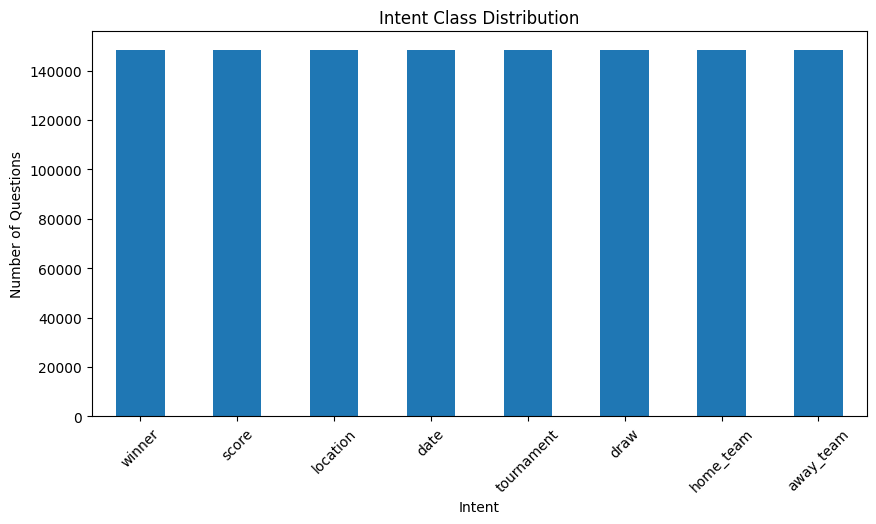

In [18]:
plt.figure(figsize=(10,5))

questions_df["intent"].value_counts().plot(kind="bar")

plt.title("Intent Class Distribution")
plt.xlabel("Intent")
plt.ylabel("Number of Questions")

plt.xticks(rotation=45)

plt.show()

# Check for Duplicate Questions

In [34]:
duplicates = questions_df["question"].duplicated().sum()

print(f"Duplicate Questions: {duplicates}")

Duplicate Questions: 437919


# Display Random Samples

In [20]:
questions_df.sample(10, random_state=42)

,question,intent,home_team,away_team,date,tournament,city,country,home_score,away_score
711367,Which city hosted the match between Bahrain an...,location,Bahrain,Trinidad and Tobago,2005-11-16,FIFA World Cup qualification,Riffa,Bahrain,0.0,1.0
662935,Which city hosted the match between Germany an...,location,Germany,Iceland,2003-10-11,UEFA Euro qualification,Hamburg,Germany,3.0,0.0
325881,When was the match between Ethiopia and Djibou...,date,Ethiopia,Djibouti,1983-03-29,Friendly,Addis Ababa,Ethiopia,4.0,2.0
377407,Which city hosted the match between Thailand a...,location,Thailand,United States,1987-06-16,Korea Cup,Cheongju,South Korea,0.0,1.0
867112,Was the match between Bermuda and Puerto Rico ...,draw,Bermuda,Puerto Rico,2012-09-07,CFU Caribbean Cup qualification,Port-au-Prince,Haiti,1.0,2.0
338414,Which tournament included the match between Ge...,tournament,Germany,Russia,1984-03-28,Friendly,Hanover,Germany,2.0,1.0
849991,Which city hosted the match between Panama and...,location,Panama,Costa Rica,2011-11-11,Friendly,Panama City,Panama,2.0,0.0
346614,Where was the match between Gabon and DR Congo...,location,Gabon,DR Congo,1984-11-25,African Cup of Nations qualification,Libreville,Gabon,1.0,1.0
612013,What competition featured Taiwan against Jordan?,tournament,Taiwan,Jordan,2001-04-25,FIFA World Cup qualification,Tashkent,Uzbekistan,0.0,2.0
760353,When was the match between Trinidad and Tobago...,date,Trinidad and Tobago,Guadeloupe,2008-02-06,Friendly,Port of Spain,Trinidad and Tobago,0.0,0.0


# Section 7.2 Data Preprocessing

# Create a Copy of the Question Column

In [51]:
questions_df["clean_question"] = questions_df["question"]

questions_df[["question", "clean_question"]].head()

,question,clean_question
0,Who won the match between Scotland and England?,Who won the match between Scotland and England?
1,Who won the match between Scotland and England...,Who won the match between Scotland and England...
2,Which team defeated Scotland on 1872-11-30?,Which team defeated Scotland on 1872-11-30?
3,What was the score between Scotland and England?,What was the score between Scotland and England?
4,What was the final score between Scotland and ...,What was the final score between Scotland and ...


# Convert Text to Lowercase

In [52]:
questions_df["clean_question"] = questions_df["clean_question"].str.lower()

questions_df[["question", "clean_question"]].head()

,question,clean_question
0,Who won the match between Scotland and England?,who won the match between scotland and england?
1,Who won the match between Scotland and England...,who won the match between scotland and england...
2,Which team defeated Scotland on 1872-11-30?,which team defeated scotland on 1872-11-30?
3,What was the score between Scotland and England?,what was the score between scotland and england?
4,What was the final score between Scotland and ...,what was the final score between scotland and ...


# Remove Punctuation and Special Characters

In [53]:
# Replace hyphens with spaces first
questions_df["clean_question"] = questions_df["clean_question"].str.replace("-", "_")

# Remove remaining punctuation
questions_df["clean_question"] = questions_df["clean_question"].str.replace(
    r"[^\w\s]",
    "",
    regex=True
)

questions_df[["question", "clean_question"]].head()

,question,clean_question
0,Who won the match between Scotland and England?,who won the match between scotland and england
1,Who won the match between Scotland and England...,who won the match between scotland and england...
2,Which team defeated Scotland on 1872-11-30?,which team defeated scotland on 1872_11_30
3,What was the score between Scotland and England?,what was the score between scotland and england
4,What was the final score between Scotland and ...,what was the final score between scotland and ...


# Tokenization

In [54]:
questions_df["tokens"] = questions_df["clean_question"].apply(word_tokenize)

questions_df[["clean_question", "tokens"]].head()

,clean_question,tokens
0,who won the match between scotland and england,"[who, won, the, match, between, scotland, and,..."
1,who won the match between scotland and england...,"[who, won, the, match, between, scotland, and,..."
2,which team defeated scotland on 1872_11_30,"[which, team, defeated, scotland, on, 1872_11_30]"
3,what was the score between scotland and england,"[what, was, the, score, between, scotland, and..."
4,what was the final score between scotland and ...,"[what, was, the, final, score, between, scotla..."


# Remove Stop Words

In [55]:
stop_words = set(stopwords.words("english"))

questions_df["tokens"] = questions_df["tokens"].apply(
    lambda words: [
        word for word in words
        if word not in stop_words
    ]
)

questions_df[["clean_question", "tokens"]].head()

,clean_question,tokens
0,who won the match between scotland and england,"[match, scotland, england]"
1,who won the match between scotland and england...,"[match, scotland, england, 1872_11_30]"
2,which team defeated scotland on 1872_11_30,"[team, defeated, scotland, 1872_11_30]"
3,what was the score between scotland and england,"[score, scotland, england]"
4,what was the final score between scotland and ...,"[final, score, scotland, england, 1872_11_30]"


# Lemmatization

In [56]:
lemmatizer = WordNetLemmatizer()

questions_df["tokens"] = questions_df["tokens"].apply(
    lambda words: [
        lemmatizer.lemmatize(word)
        for word in words
    ]
)

questions_df[["clean_question", "tokens"]].head()

,clean_question,tokens
0,who won the match between scotland and england,"[match, scotland, england]"
1,who won the match between scotland and england...,"[match, scotland, england, 1872_11_30]"
2,which team defeated scotland on 1872_11_30,"[team, defeated, scotland, 1872_11_30]"
3,what was the score between scotland and england,"[score, scotland, england]"
4,what was the final score between scotland and ...,"[final, score, scotland, england, 1872_11_30]"


# Convert Tokens Back to Text

In [57]:
questions_df["clean_question"] = questions_df["tokens"].apply(
    lambda words: " ".join(words)
)

questions_df[["question", "clean_question"]].head()

,question,clean_question
0,Who won the match between Scotland and England?,match scotland england
1,Who won the match between Scotland and England...,match scotland england 1872_11_30
2,Which team defeated Scotland on 1872-11-30?,team defeated scotland 1872_11_30
3,What was the score between Scotland and England?,score scotland england
4,What was the final score between Scotland and ...,final score scotland england 1872_11_30


# Compare Original and Cleaned Questions

In [58]:
questions_df[
    ["question", "clean_question", "intent"]
].sample(10, random_state=42)

,question,clean_question,intent
711367,Which city hosted the match between Bahrain an...,city hosted match bahrain trinidad tobago 2005...,location
662935,Which city hosted the match between Germany an...,city hosted match germany iceland 2003_10_11,location
325881,When was the match between Ethiopia and Djibou...,match ethiopia djibouti played,date
377407,Which city hosted the match between Thailand a...,city hosted match thailand united state 1987_0...,location
867112,Was the match between Bermuda and Puerto Rico ...,match bermuda puerto rico 2012_09_07 draw,draw
338414,Which tournament included the match between Ge...,tournament included match germany russia 1984_...,tournament
849991,Which city hosted the match between Panama and...,city hosted match panama costa rica 2011_11_11,location
346614,Where was the match between Gabon and DR Congo...,match gabon dr congo played,location
612013,What competition featured Taiwan against Jorda...,competition featured taiwan jordan 2001_04_25,tournament
760353,When was the match between Trinidad and Tobago...,match trinidad tobago guadeloupe played,date
